## 04 Location or Size: What Influences House Prices in Mexico?

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Import Data
df = pd.read_csv("data/mexico-real-estate-clean.csv")

## Research Question 1

**Which state has the most expensive real estate market?**

**Task2:** Use groupyby method to create a series named "mean_price_by_state" where the index contains easch state in the dataset and the values correspond to the mean house price for that state.

In [3]:
mean_price_by_state = df.groupby("state")["price_usd"].mean().sort_values(ascending=False)
mean_price_by_state

state
Querétaro                          132542.931477
Nuevo León                         131632.140345
Guanajuato                         128933.559000
Jalisco                            123683.233784
Quintana Roo                       123481.853913
Distrito Federal                   123316.527867
Guerrero                           123105.097407
Puebla                             122794.490000
Estado de México                   121751.102960
Campeche                           121734.633333
Morelos                            121558.557928
Baja California Sur                116051.237778
Sonora                             114788.850000
Yucatán                            108759.922143
Chiapas                            108239.040714
Hidalgo                            106915.692000
Aguascalientes                     105555.603333
Chihuahua                          103390.629167
San Luis Potosí                     95993.655405
Veracruz de Ignacio de la Llave     95852.838537
Tabasco       

**Task3:** Use "mean_price_by_state" to create a bar chart for the results.
    make sure states are sorted from highest to lowest mean
    label x axis as "State"
    label y axis as "Mean Price [USD]"
    title as "Mean House Price by State"


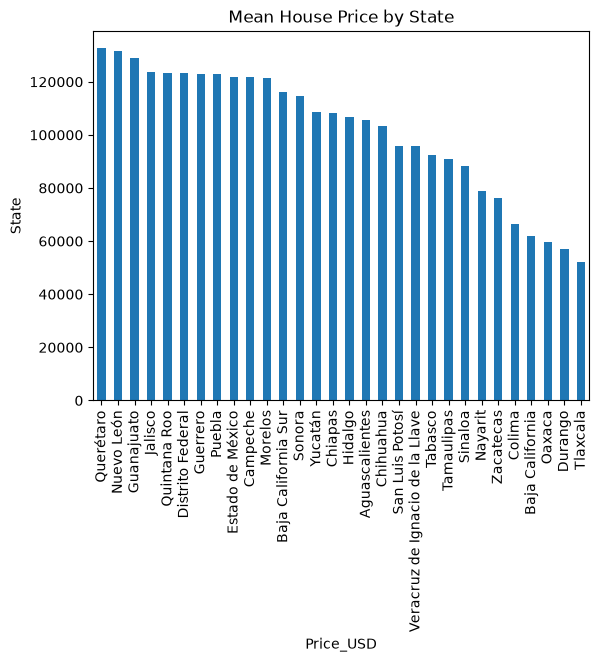

In [4]:
mean_price_by_state.plot(
    kind="bar",
    ylabel="State",
    xlabel="Price_USD",
    title="Mean House Price by State"

    
);

**Task4**: Create a new column in df called "price_per_m2".This should be the price for each house divided by it's size

In [5]:
df["price_per_m2"] = df["price_usd"] / df["area_m2"]
df.head()

,property_type,state,lat,lon,area_m2,price_usd,price_per_m2
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56,453.103733
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78,339.912796
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37,1028.028902
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80,628.725333
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37,513.128634


**Task5:** First, use the groupby method to create a Series where the index contains each state in the dataset and the values correspond to the mean house price per m2 for that state. Then use the Series to create a bar chart of your results. Make sure the states are sorted from the highest to lowest mean, that you label the x-axis as "State" and the y-axis as "Mean Price per M^2[USD]", and give the chart the title "Mean House Price per M^2 by State".



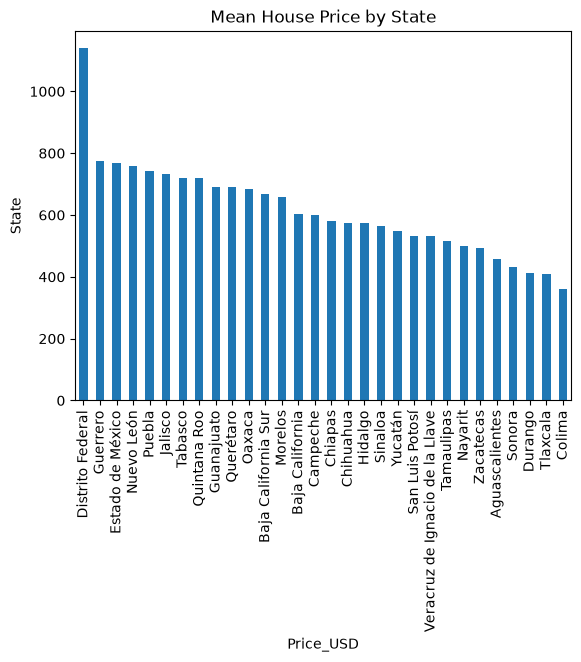

In [6]:
(
    df
    .groupby("state")
    ["price_per_m2"].mean()
    .sort_values(ascending=False)
    .plot(
        kind="bar",
        ylabel="State",
        xlabel="Price_USD",
        title="Mean House Price by State"

        
    )
);

## Research Question 2

**Is there a relationship between home size and price?**

**Task6:** Create a scatter plot from df that represents price as a function of size. In other words, "area_m2" should be on the x-axis, and "price_usd" should be on the y-axis. Be sure to use expressive axis labels ("Area [sq meters]" and "Price [USD]", respectively).

Text(0.5, 1.0, 'Price vs Area')

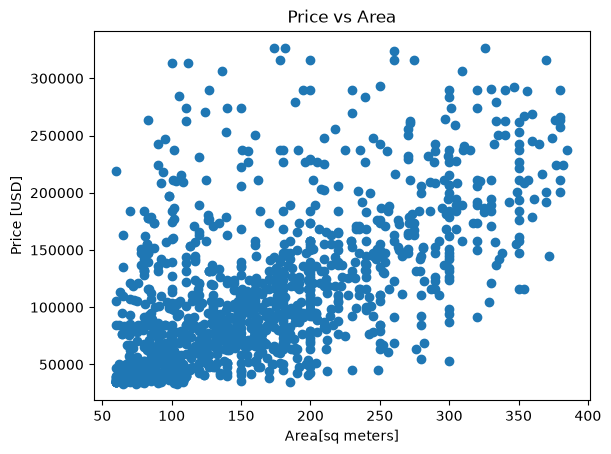

In [7]:
plt.scatter(x=df["area_m2"], y=df["price_usd"])
plt.xlabel("Area[sq meters]")
plt.ylabel("Price [USD]")
plt.title("Price vs Area")

**Task7:** Using the corr method, calculate the Pearson correlation coefficient for "area_m2" and "price_usd".

In [8]:
p_correlation = df["area_m2"].corr(df["price_usd"])
print(p_correlation )

0.597199092597283


**Task8:** Create a new DataFrame named df_morelos. It should include all the houses from df that are in the state of Morelos.

In [9]:
df.head()

,property_type,state,lat,lon,area_m2,price_usd,price_per_m2
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56,453.103733
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78,339.912796
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37,1028.028902
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80,628.725333
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37,513.128634


In [10]:
df_morelos = df[df["state"] == "Morelos"]
df_morelos.head(10)

,property_type,state,lat,lon,area_m2,price_usd,price_per_m2
6,house,Morelos,18.812605,-98.954826,281.0,151509.56,539.179929
9,house,Morelos,18.804197,-98.932816,117.0,63223.78,540.374188
18,house,Morelos,18.855343,-99.241142,73.0,36775.16,503.769315
49,house,Morelos,18.804197,-98.932816,130.0,65858.10,506.600769
55,house,Morelos,18.960244,-99.212962,305.0,227351.46,745.414623
89,house,Morelos,18.942068,-99.242531,290.0,242415.29,835.914793
93,house,Morelos,18.917542,-98.963181,220.0,110641.61,502.916409
107,house,Morelos,18.918608,-98.941094,247.0,142287.24,576.061700
132,house,Morelos,18.903454,-99.056687,145.0,89567.02,617.703586
134,house,Morelos,18.891792,-99.222722,183.0,147557.13,806.323115


In [11]:
df_morelos.shape

(160, 7)

**Task9:** Using df_morelos, create a scatter plot that shows price vs area. Make sure to use the same axis labels as your last scatter plot. The title should be "Morelos: Price vs. Area"

Text(0.5, 1.0, 'Morelos: Price vs Area')

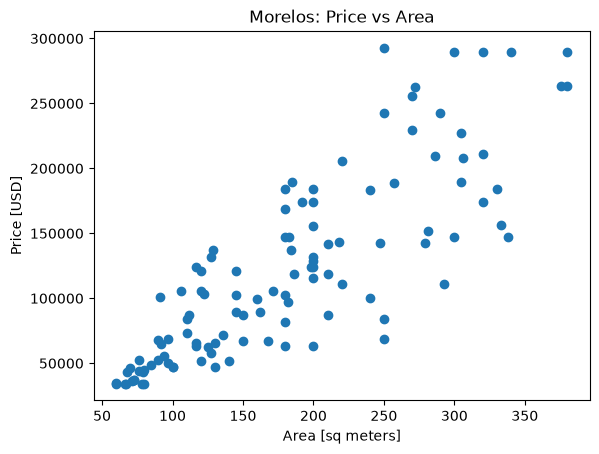

In [12]:
plt.scatter(x=df_morelos["area_m2"], y=df_morelos["price_usd"])
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Morelos: Price vs Area")

**Task10:** Using the corr method, calculate the Pearson correlation coefficient for "area_m2" and "price_usd" in df_morelos.

In [13]:
p_correlation = df_morelos["area_m2"].corr(df_morelos["price_usd"])
print(p_correlation)

0.8330503324907604


nan


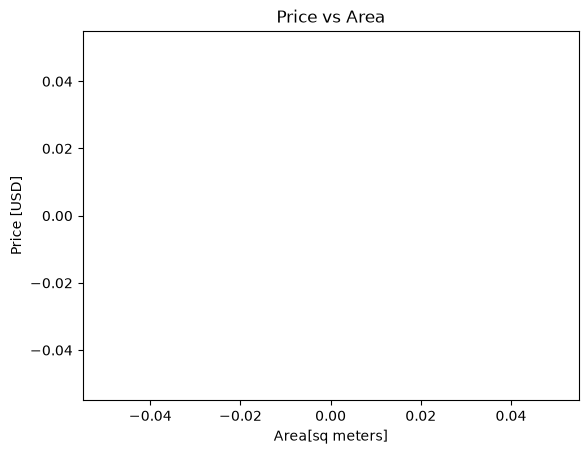

In [18]:
df_mexico_city = df[df["state"] == "Distriro Federal"]

#Create a scatter plot price vs area
plt.scatter(x=df_mexico_city ["area_m2"], y=df_mexico_city ["price_usd"])
plt.xlabel("Area[sq meters]")
plt.ylabel("Price [USD]")
plt.title("Price vs Area")

p_correlation =  df_mexico_city["area_m2"].corr(df_mexico_city["price_usd"])
print(p_correlation )